## Load and download tensorflow and tensorflow dataset


In [1]:
pip install tensorflow 

Note: you may need to restart the kernel to use updated packages.


In [2]:
pip install tensorflow tensorflow-datasets

Note: you may need to restart the kernel to use updated packages.


## Import libraries

In [3]:
import tensorflow as tf
import tensorflow_datasets as tfds
import pathlib
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.applications import VGG16
from tensorflow.keras.applications import InceptionV3
from tensorflow.keras.applications import DenseNet121
from tensorflow.keras.layers import Dense, Flatten, Dropout
from tensorflow.keras.models import Model
from tensorflow.keras import layers
from tensorflow.keras.models import Sequential
from keras.utils import to_categorical
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import numpy as np
import os 

print("TensorFlow version:", tf.__version__)
print("TensorFlow Datasets version:", tfds.__version__)


2026-05-15 13:59:33.354550: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1778853573.520800      24 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1778853573.570071      24 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1778853573.980123      24 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1778853573.980162      24 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1778853573.980164      24 computation_placer.cc:177] computation placer alr

TensorFlow version: 2.19.0
TensorFlow Datasets version: 4.9.9


In [4]:
dataset_url = "https://storage.googleapis.com/download.tensorflow.org/example_images/flower_photos.tgz"
data_dir = tf.keras.utils.get_file('flower_photos', origin=dataset_url, untar=True)
#download and extract the dataset
#run once


228813984/228813984 ━━━━━━━━━━━━━━━━━━━━ 8s 0us/step


In [5]:
data_dir = pathlib.Path(data_dir)/"flower_photos"
print("Dataset directory:", data_dir)

Dataset directory: /root/.keras/datasets/flower_photos/flower_photos


In [6]:
img_height = 224
img_width = 224
batch_size = 32
full_ds = tf.keras.utils.image_dataset_from_directory(
    data_dir,
    seed=123,
    image_size=(img_height, img_width),
    shuffle=True
)

class_names = full_ds.class_names
num_classes = len(class_names)

print("Class names:", class_names)
print("Number of classes:", num_classes)


Found 3670 files belonging to 5 classes.


I0000 00:00:1778853608.832773      24 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1778853608.838630      24 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13757 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


Class names: ['daisy', 'dandelion', 'roses', 'sunflowers', 'tulips']
Number of classes: 5


In [7]:
#check for all the folders in the dataset directory
print("\nFolder Check:\n")

for class_name in class_names:
    class_path = os.path.join(data_dir, class_name)
    exists = os.path.exists(class_path)
    print(f"{class_name}: {exists}")


Folder Check:

daisy: True
dandelion: True
roses: True
sunflowers: True
tulips: True


### Load the dataset, and display 10 sample images.2 flower images from 5 different classes

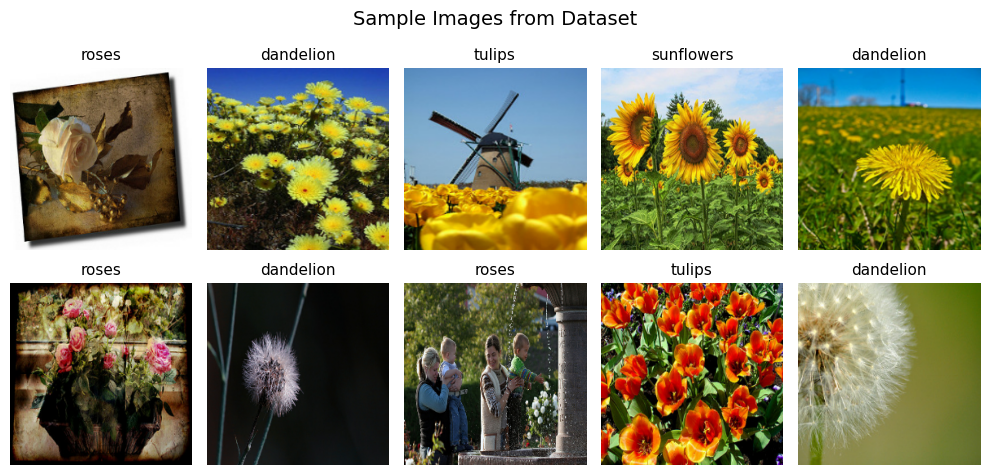

In [8]:
# Get class names

class_names = full_ds.class_names

num_images_to_display = 10

plt.figure(figsize=(10, 5))

for i, (images, labels) in enumerate(full_ds.take(1)):
    for j in range(num_images_to_display):
        plt.subplot(2, 5, j + 1)
        plt.imshow(images[j].numpy().astype("uint8"))
        plt.title(class_names[labels[j].numpy()], fontsize=11)
        plt.axis("off")

plt.suptitle("Sample Images from Dataset", fontsize=14)
plt.tight_layout()
plt.show()

## Data Preprocessing

### Data splitting and image resizing 

In [9]:
total_batches = tf.data.experimental.cardinality(full_ds).numpy()
print("Total batches:", total_batches)

train_size = int(0.8 * total_batches)
val_size = int(0.1 * total_batches)

train_ds = full_ds.take(train_size)
temp_ds = full_ds.skip(train_size)

val_ds = temp_ds.take(val_size)
test_ds = temp_ds.skip(val_size)


Total batches: 115


In [10]:
train_batches = tf.data.experimental.cardinality(train_ds).numpy()
val_batches   = tf.data.experimental.cardinality(val_ds).numpy()
test_batches  = tf.data.experimental.cardinality(test_ds).numpy()

print("Train batches:", train_batches)
print("Val batches:", val_batches)
print("Test batches:", test_batches)

print("\nimage counts for:")

print("Train images :", train_batches * batch_size)
print("Val images :", val_batches * batch_size)
print("Test images :", test_batches * batch_size)


Train batches: 92
Val batches: 11
Test batches: 12

image counts for:
Train images : 2944
Val images : 352
Test images : 384


### Diplay images from training dataset

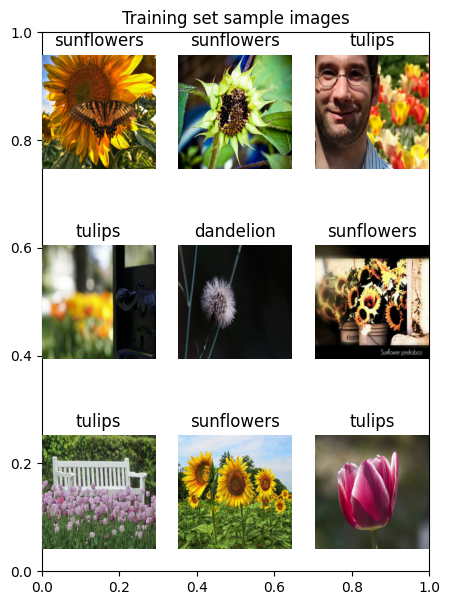

In [11]:
plt.figure(figsize=(5,7))
plt.title("Training set sample images")
for images, labels in train_ds.take(1):
    for i in range(9):
        ax = plt.subplot(3, 3, i + 1)
        plt.imshow(images[i].numpy().astype("uint8"))  # ✅ important
        plt.title(class_names[labels[i]])
        plt.axis("off")

plt.axis("off")
plt.show()

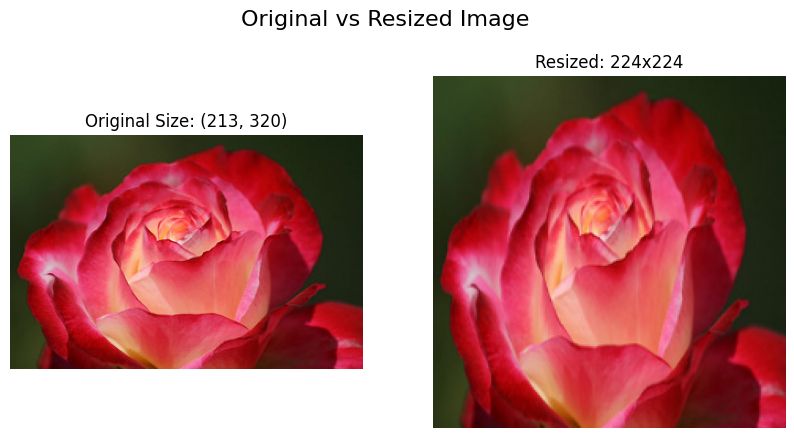

In [12]:
# Load one image manually (original size)
for image_path in data_dir.glob('*/*.jpg'):
    img = tf.keras.utils.load_img(image_path)  # original size
    img_array = tf.keras.utils.img_to_array(img)
    break

# Resize image
resized_img = tf.image.resize(img_array, (224, 224))

# Display
plt.figure(figsize=(10,5))
plt.suptitle("Original vs Resized Image", fontsize=16)
# Original Image
plt.subplot(1,2,1)
plt.imshow(img_array.astype("uint8"))
plt.title(f"Original Size: {img_array.shape[:2]}")
plt.axis("off")

# Resized Image
plt.subplot(1,2,2)
plt.imshow(resized_img.numpy().astype("uint8"))
plt.title("Resized: 224x224")
plt.axis("off")

plt.show()

### Data augmentation and normalization(e.g., random flips, rotations,zoom and translation)


In [13]:
AUTOTUNE = tf.data.AUTOTUNE

data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal"),
    tf.keras.layers.RandomRotation(0.1),
    tf.keras.layers.RandomTranslation(0.1, 0.1),
    tf.keras.layers.RandomZoom(0.1),
])

normalization_layer = tf.keras.layers.Rescaling(1./255)

train_ds = train_ds.map(
    lambda x, y: (data_augmentation(normalization_layer(x), training=True), y),
    num_parallel_calls=AUTOTUNE
)

val_ds = val_ds.map(
    lambda x, y: (normalization_layer(x), y),
    num_parallel_calls=AUTOTUNE
)
test_ds = test_ds.map(
    lambda x, y: (normalization_layer(x), y),
    num_parallel_calls=AUTOTUNE
)

test_ds = test_ds.prefetch(AUTOTUNE)
train_ds = train_ds.prefetch(AUTOTUNE)
val_ds = val_ds.prefetch(AUTOTUNE)

### Display augmented images and original images 

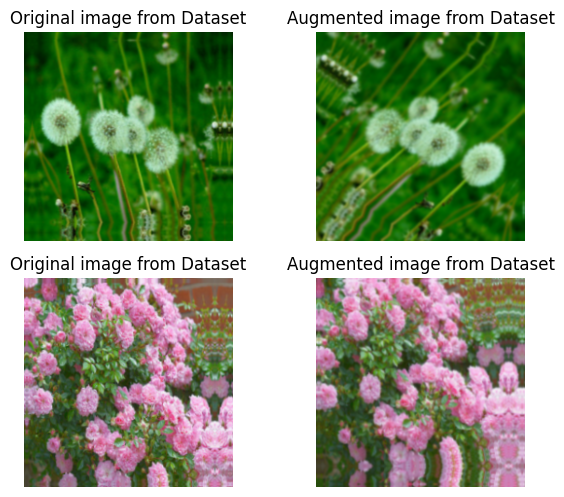

In [14]:
for images, labels in train_ds.take(1):
    original_images = images
    original_labels = labels

augmented_images = data_augmentation(original_images, training=True)

plt.figure(figsize=(6, 10))

for i in range(2):
    # Original
    ax = plt.subplot(4, 2, 2*i + 1)
    plt.imshow(original_images[i])
    plt.title("Original image from Dataset")
    plt.axis("off")

    # Augmented
    ax = plt.subplot(4, 2, 2*i + 2)
    plt.imshow(augmented_images[i])
    plt.title("Augmented image from Dataset")
    plt.axis("off")

plt.tight_layout()
plt.show()

#### Check image size

In [15]:
for images, labels in train_ds.take(1):
    print(images.shape)

(32, 224, 224, 3)


###  Load Pre-trained VGG16 Model

In [16]:
# Load the VGG16 model with pre-trained ImageNet weights
base_model = VGG16(weights='imagenet', include_top=False, input_shape=(img_height, img_width, 3))

58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


In [17]:
# 2. Freeze the layers of the VGG16 base model
base_model.trainable = False

In [18]:
vgg_model = base_model.output
vgg_model = Flatten()(vgg_model)
vgg_model = Dense(256,activation='relu')(vgg_model) # 256 neurons
vgg_model = Dropout(0.5)(vgg_model)
vgg_model = Dense(5,activation='softmax')(vgg_model)
vgg_model = Model(inputs=base_model.input,outputs=vgg_model)

In [19]:
print("VGG16 base model summary:")
vgg_model.summary()

VGG16 base model summary:


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv1 (Conv2D)           │ (None, 224, 224, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, 224, 224, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, 112, 112, 128)  │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, 112, 112, 128)  │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv1 (Conv2D)           │ (None, 56, 56, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv2 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv3 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_pool (MaxPooling2D)      │ (None, 28, 28, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv1 (Conv2D)           │ (None, 28, 28, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv2 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv3 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_pool (MaxPooling2D)      │ (None, 14, 14, 512)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv1 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv2 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv3 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_pool (MaxPooling2D)      │ (None, 7, 7, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │     6,422,784 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 5)              │         1,285 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 21,138,757 (80.64 MB)

 Trainable params: 6,424,069 (24.51 MB)

 Non-trainable params: 14,714,688 (56.13 MB)

In [20]:
#compile the model with optimize the performance of vgg16
vgg_model.compile(optimizer=Adam(learning_rate=0.0001),loss='sparse_categorical_crossentropy',metrics=['accuracy'])

## Train Model

In [21]:
# Train the model
epochs = 20
vgg_history = vgg_model.fit(
    train_ds,
    epochs=epochs,
    validation_data=val_ds
)

print(f"Model trained for {epochs} epochs.")

Epoch 1/20


I0000 00:00:1778853622.256368      87 service.cc:152] XLA service 0x7cfd60001220 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1778853622.256406      87 service.cc:160]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1778853622.256411      87 service.cc:160]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1778853622.960212      87 cuda_dnn.cc:529] Loaded cuDNN version 91002


 1/92 ━━━━━━━━━━━━━━━━━━━━ 23:35 16s/step - accuracy: 0.1875 - loss: 2.2274

I0000 00:00:1778853635.667181      87 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


92/92 ━━━━━━━━━━━━━━━━━━━━ 38s 251ms/step - accuracy: 0.4551 - loss: 1.3996 - val_accuracy: 0.7159 - val_loss: 0.7415
Epoch 2/20
92/92 ━━━━━━━━━━━━━━━━━━━━ 23s 241ms/step - accuracy: 0.7050 - loss: 0.7836 - val_accuracy: 0.7784 - val_loss: 0.6070
Epoch 3/20
92/92 ━━━━━━━━━━━━━━━━━━━━ 23s 242ms/step - accuracy: 0.7386 - loss: 0.6954 - val_accuracy: 0.8182 - val_loss: 0.5307
Epoch 4/20
92/92 ━━━━━━━━━━━━━━━━━━━━ 23s 245ms/step - accuracy: 0.7763 - loss: 0.6312 - val_accuracy: 0.8068 - val_loss: 0.5561
Epoch 5/20
92/92 ━━━━━━━━━━━━━━━━━━━━ 23s 247ms/step - accuracy: 0.7733 - loss: 0.6105 - val_accuracy: 0.8040 - val_loss: 0.5744
Epoch 6/20
92/92 ━━━━━━━━━━━━━━━━━━━━ 23s 247ms/step - accuracy: 0.7948 - loss: 0.5786 - val_accuracy: 0.7898 - val_loss: 0.5624
Epoch 7/20
92/92 ━━━━━━━━━━━━━━━━━━━━ 23s 245ms/step - accuracy: 0.8174 - loss: 0.5283 - val_accuracy: 0.8267 - val_loss: 0.4588
Epoch 8/20
92/92 ━━━━━━━━━━━━━━━━━━━━ 24s 249ms/step - accuracy: 0.8269 - loss: 0.5010 - val_accuracy: 0.835

## Model training evaluation 

In [22]:
train_loss_vgg, train_acc_vgg = vgg_model.evaluate(train_ds)
val_loss_vgg, val_acc_vgg = vgg_model.evaluate(val_ds)
test_loss_vgg, test_acc_vgg = vgg_model.evaluate(test_ds)

92/92 ━━━━━━━━━━━━━━━━━━━━ 19s 201ms/step - accuracy: 0.8961 - loss: 0.2762
11/11 ━━━━━━━━━━━━━━━━━━━━ 4s 172ms/step - accuracy: 0.8849 - loss: 0.3127
12/12 ━━━━━━━━━━━━━━━━━━━━ 14s 1s/step - accuracy: 0.8324 - loss: 0.4713


In [23]:
print("\nVGG16 Model Performance in tfds:")
print("Training Loss:", round(train_loss_vgg, 4))
print("Training Accuracy:", round(train_acc_vgg * 100, 2), "%")

print("\nValidation Loss:", round(val_loss_vgg, 4))
print("Validation Accuracy:", round(val_acc_vgg * 100, 2), "%")

print("\nTest Loss:", round(test_loss_vgg, 4))
print("Test Accuracy:", round(test_acc_vgg * 100, 2), "%")


VGG16 Model Performance in tfds:
Training Loss: 0.2623
Training Accuracy: 90.76 %

Validation Loss: 0.3396
Validation Accuracy: 87.78 %

Test Loss: 0.4406
Test Accuracy: 84.22 %


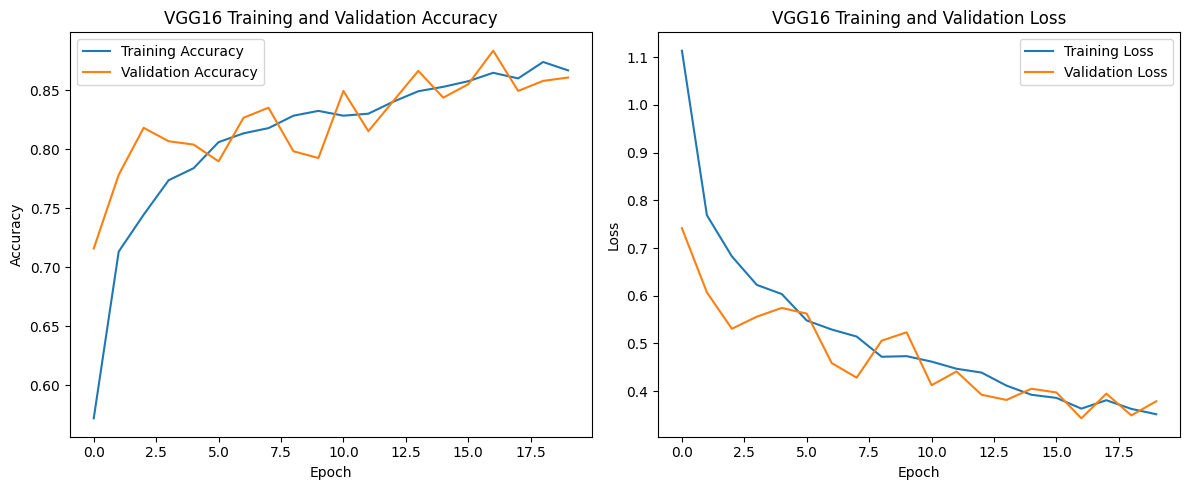

In [24]:
# Plot training and validation accuracy
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(vgg_history.history['accuracy'], label='Training Accuracy')
plt.plot(vgg_history.history['val_accuracy'], label='Validation Accuracy')
plt.title('VGG16 Training and Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

# Plot training and validation loss
plt.subplot(1, 2, 2)
plt.plot(vgg_history.history['loss'], label='Training Loss')
plt.plot(vgg_history.history['val_loss'], label='Validation Loss')
plt.title('VGG16 Training and Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()

In [25]:
# Get true labels and predictions
y_true_vgg = []
y_pred_vgg = []

for images, labels in test_ds:
    preds = vgg_model.predict(images, verbose=0)
    preds = np.argmax(preds, axis=1)

    y_true_vgg.extend(labels.numpy())
    y_pred_vgg.extend(preds)

# Generate classification report
print("\nVGG16 Classification Report(tensorflow dataset):")
print(classification_report(y_true_vgg, y_pred_vgg, target_names=class_names))


VGG16 Classification Report(tensorflow dataset):
              precision    recall  f1-score   support

       daisy       0.87      0.86      0.87        71
   dandelion       0.96      0.86      0.90        83
       roses       0.79      0.85      0.82        71
  sunflowers       0.83      0.81      0.82        74
      tulips       0.80      0.88      0.84        75

    accuracy                           0.85       374
   macro avg       0.85      0.85      0.85       374
weighted avg       0.85      0.85      0.85       374



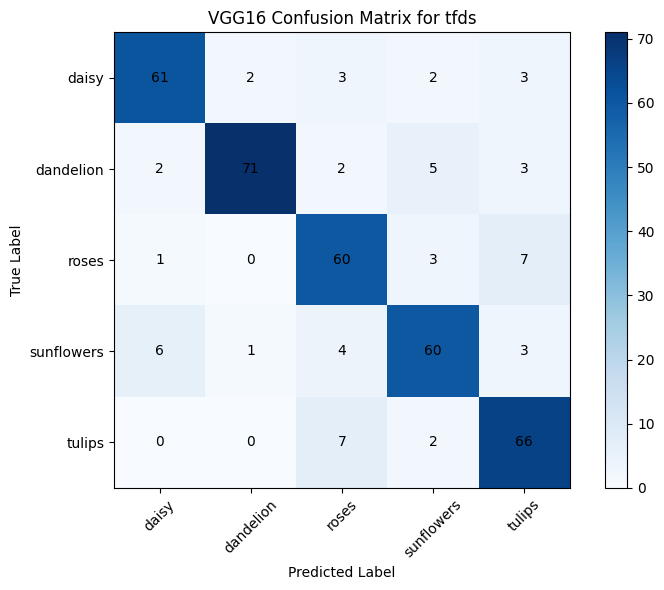

In [26]:
cm = confusion_matrix(y_true_vgg, y_pred_vgg)

plt.figure(figsize=(8, 6))
plt.imshow(cm,cmap="Blues")
plt.title("VGG16 Confusion Matrix for tfds")
plt.colorbar()

plt.xticks(range(len(class_names)), class_names, rotation=45)
plt.yticks(range(len(class_names)), class_names)

for i in range(len(class_names)):
    for j in range(len(class_names)):
        plt.text(j, i, cm[i, j], ha="center", va="center")

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.tight_layout()
plt.show()


In [27]:
vgg_model.save("vgg16_tfds_20.keras")
print("VGG16 model saved successfully.")

VGG16 model saved successfully.


## Inception V3

In [28]:
base_inceptionV3 = tf.keras.applications.InceptionV3(
    input_shape=(224, 224, 3),
    include_top=False,
    weights="imagenet"
)

#unfreeze the base layer
base_inceptionV3.trainable = True

for layer in base_inceptionV3.layers[:-50]:
    layer.trainable = False

87910968/87910968 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


In [29]:
model_inc = tf.keras.Sequential([
    base_inceptionV3,
    tf.keras.layers.GlobalAveragePooling2D(),
    tf.keras.layers.Dropout(0.5),
    tf.keras.layers.Dense(256, activation="relu"),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.Dense(5, activation="softmax")
])


In [30]:
model_inc.compile(
    optimizer=tf.keras.optimizers.Adam(0.0001),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
    
)

In [31]:
model_inc.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ inception_v3 (Functional)       │ (None, 5, 5, 2048)     │    21,802,784 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 2048)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 256)            │       524,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_94          │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 5)              │         1,285 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 22,329,637 (85.18 MB)

 Trainable params: 7,699,653 (29.37 MB)

 Non-trainable params: 14,629,984 (55.81 MB)

In [32]:
early_stop = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True
)

In [33]:
history_inc = model_inc.fit(
    train_ds,
    validation_data=val_ds,
    epochs=20,
    callbacks =[early_stop]
)

Epoch 1/20
92/92 ━━━━━━━━━━━━━━━━━━━━ 54s 293ms/step - accuracy: 0.5324 - loss: 1.2852 - val_accuracy: 0.8409 - val_loss: 0.3910
Epoch 2/20
92/92 ━━━━━━━━━━━━━━━━━━━━ 22s 227ms/step - accuracy: 0.8292 - loss: 0.4724 - val_accuracy: 0.8835 - val_loss: 0.3000
Epoch 3/20
92/92 ━━━━━━━━━━━━━━━━━━━━ 21s 224ms/step - accuracy: 0.8663 - loss: 0.3884 - val_accuracy: 0.9062 - val_loss: 0.2579
Epoch 4/20
92/92 ━━━━━━━━━━━━━━━━━━━━ 21s 221ms/step - accuracy: 0.9008 - loss: 0.2757 - val_accuracy: 0.9205 - val_loss: 0.2131
Epoch 5/20
92/92 ━━━━━━━━━━━━━━━━━━━━ 21s 218ms/step - accuracy: 0.9252 - loss: 0.2097 - val_accuracy: 0.9261 - val_loss: 0.2192
Epoch 6/20
92/92 ━━━━━━━━━━━━━━━━━━━━ 21s 218ms/step - accuracy: 0.9409 - loss: 0.1846 - val_accuracy: 0.9375 - val_loss: 0.1969
Epoch 7/20
92/92 ━━━━━━━━━━━━━━━━━━━━ 21s 217ms/step - accuracy: 0.9387 - loss: 0.1711 - val_accuracy: 0.9261 - val_loss: 0.1995
Epoch 8/20
92/92 ━━━━━━━━━━━━━━━━━━━━ 21s 225ms/step - accuracy: 0.9586 - loss: 0.1316 - val_accu

In [34]:
train_loss_inc, train_acc_inc = model_inc.evaluate(train_ds)
val_loss_inc, val_acc_inc = model_inc.evaluate(val_ds)
test_loss_inc, test_acc_inc = model_inc.evaluate(test_ds)

print("\nInceptionV3 Model Performance (tensorflow dataset):")
print("Training Loss:", round(train_loss_inc, 4))
print("Training Accuracy:", round(train_acc_inc * 100, 2), "%")

print("\nValidation Loss:", round(val_loss_inc, 4))
print("Validation Accuracy:", round(val_acc_inc * 100, 2), "%")

print("\nTest Loss:", round(test_loss_inc, 4))
print("Test Accuracy:", round(test_acc_inc * 100, 2), "%")

92/92 ━━━━━━━━━━━━━━━━━━━━ 18s 185ms/step - accuracy: 0.9938 - loss: 0.0143
11/11 ━━━━━━━━━━━━━━━━━━━━ 3s 68ms/step - accuracy: 0.9722 - loss: 0.1115
12/12 ━━━━━━━━━━━━━━━━━━━━ 9s 632ms/step - accuracy: 0.9601 - loss: 0.1110

InceptionV3 Model Performance (tensorflow dataset):
Training Loss: 0.0188
Training Accuracy: 99.35 %

Validation Loss: 0.1615
Validation Accuracy: 96.31 %

Test Loss: 0.1621
Test Accuracy: 95.72 %


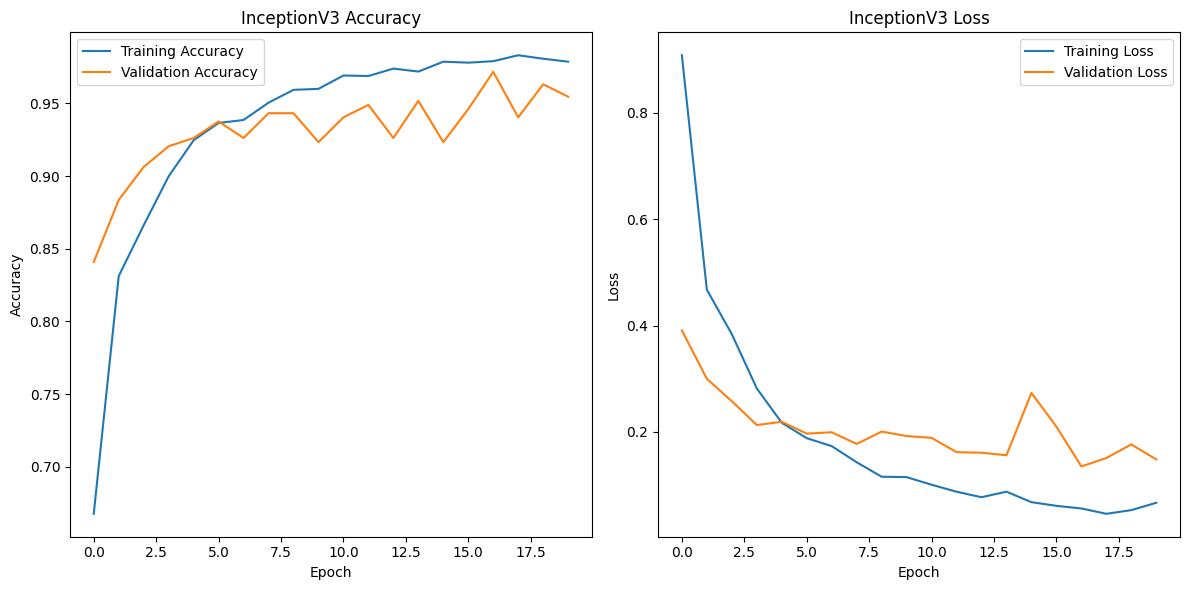

In [35]:
plt.figure(figsize=(12, 6))
#show the training and validation accuracy and loss for inceptionV3
plt.subplot(1, 2, 1)
plt.plot(history_inc.history["accuracy"], label="Training Accuracy")
plt.plot(history_inc.history["val_accuracy"], label="Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.title("InceptionV3 Accuracy")

plt.subplot(1, 2, 2)
plt.plot(history_inc.history["loss"], label="Training Loss")
plt.plot(history_inc.history["val_loss"], label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("InceptionV3 Loss")
plt.legend()

plt.tight_layout()
plt.show()

In [36]:
#Get Predictions from Test Set
y_true_inc = []
y_pred_inc = []

for images, labels in test_ds:
    predictions = model_inc.predict(images)
    y_true_inc.extend(labels.numpy())
    y_pred_inc.extend(np.argmax(predictions, axis=1))

y_true_inc = np.array(y_true_inc)
y_pred_inc = np.array(y_pred_inc)
print("InceptionV3 Classification Output for Test set:\n")
print(classification_report(y_true_inc, y_pred_inc, target_names=class_names))

1/1 ━━━━━━━━━━━━━━━━━━━━ 6s 6s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 130ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 130ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 123ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 123ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 124ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 126ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 109ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 107ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 117ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 106ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 6s 6s/step
InceptionV3 Classification Output for Test set:

              precision    recall  f1-score   support

       daisy       0.99      0.97      0.98        68
   dandelion       0.98      0.98      0.98        85
       roses       0.87      0.97      0.92        63
  sunflowers       1.00      0.96      0.98        72
      tulips       0.92      0.88      0.90        86

    accuracy                           0.95       374
   macro avg       0.95      0.95      0.95       374
weighted avg       0.95      0.95      0.95       374



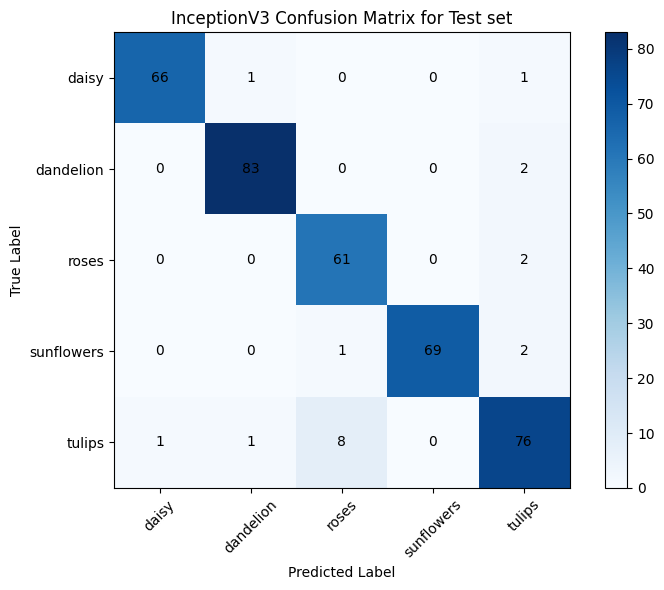

In [37]:
cm = confusion_matrix(y_true_inc, y_pred_inc)

plt.figure(figsize=(8, 6))
plt.imshow(cm,cmap="Blues")
plt.title("InceptionV3 Confusion Matrix for Test set")
plt.colorbar()

plt.xticks(range(len(class_names)), class_names, rotation=45)
plt.yticks(range(len(class_names)), class_names)

for i in range(len(class_names)):
    for j in range(len(class_names)):
        plt.text(j, i, cm[i, j], ha="center", va="center")

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.tight_layout()
plt.show()

In [38]:
model_inc.save("inceptionV3_tfds_20.keras")
print("Model saved successfully")

Model saved successfully


## DenseNet-121

In [39]:
denseNet_base = DenseNet121(weights='imagenet', include_top=False, pooling='avg', input_shape=(img_height, img_width, 3))

29084464/29084464 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


In [40]:
denseNet_base.trainable = False

In [41]:
densenet_model = tf.keras.Sequential([
    denseNet_base,
    layers.Dense(256, activation="relu"),
    layers.BatchNormalization(),
    layers.Dropout(0.3),
    layers.Dense(5, activation="softmax")
])

In [42]:
densenet_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [43]:
densenet_model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ densenet121 (Functional)        │ (None, 1024)           │     7,037,504 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 256)            │       262,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_95          │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 5)              │         1,285 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,302,213 (27.86 MB)

 Trainable params: 264,197 (1.01 MB)

 Non-trainable params: 7,038,016 (26.85 MB)

In [44]:
history_densenet = densenet_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=20,
)

Epoch 1/20
92/92 ━━━━━━━━━━━━━━━━━━━━ 59s 340ms/step - accuracy: 0.3483 - loss: 1.8518 - val_accuracy: 0.7585 - val_loss: 0.7061
Epoch 2/20
92/92 ━━━━━━━━━━━━━━━━━━━━ 21s 220ms/step - accuracy: 0.7007 - loss: 0.8209 - val_accuracy: 0.8438 - val_loss: 0.4630
Epoch 3/20
92/92 ━━━━━━━━━━━━━━━━━━━━ 21s 220ms/step - accuracy: 0.7649 - loss: 0.6386 - val_accuracy: 0.8466 - val_loss: 0.4224
Epoch 4/20
92/92 ━━━━━━━━━━━━━━━━━━━━ 21s 219ms/step - accuracy: 0.7979 - loss: 0.5453 - val_accuracy: 0.8807 - val_loss: 0.3188
Epoch 5/20
92/92 ━━━━━━━━━━━━━━━━━━━━ 21s 222ms/step - accuracy: 0.8308 - loss: 0.4813 - val_accuracy: 0.8722 - val_loss: 0.3229
Epoch 6/20
92/92 ━━━━━━━━━━━━━━━━━━━━ 21s 221ms/step - accuracy: 0.8258 - loss: 0.4581 - val_accuracy: 0.8977 - val_loss: 0.2789
Epoch 7/20
92/92 ━━━━━━━━━━━━━━━━━━━━ 21s 221ms/step - accuracy: 0.8546 - loss: 0.3918 - val_accuracy: 0.9034 - val_loss: 0.2699
Epoch 8/20
92/92 ━━━━━━━━━━━━━━━━━━━━ 21s 225ms/step - accuracy: 0.8467 - loss: 0.4111 - val_accu

In [45]:
train_loss_densenet, train_acc_densenet = densenet_model.evaluate(train_ds)
val_loss_densenet, val_acc_densenet = densenet_model.evaluate(val_ds)
test_loss_densenet, test_acc_densenet = densenet_model.evaluate(test_ds)
print("\nDenseNet121 Model Performance (tensorflow dataset):")
print("Training Loss:", round(train_loss_densenet, 4))
print("Training Accuracy:", round(train_acc_densenet * 100, 2), "%")

print("\nValidation Loss:", round(val_loss_densenet, 4))
print("Validation Accuracy:", round(val_acc_densenet * 100, 2), "%")

print("\nTest Loss:", round(test_loss_densenet, 4))
print("Test Accuracy:", round(test_acc_densenet * 100, 2), "%")

92/92 ━━━━━━━━━━━━━━━━━━━━ 19s 195ms/step - accuracy: 0.9396 - loss: 0.1861
11/11 ━━━━━━━━━━━━━━━━━━━━ 3s 83ms/step - accuracy: 0.8927 - loss: 0.2460
12/12 ━━━━━━━━━━━━━━━━━━━━ 15s 1s/step - accuracy: 0.9288 - loss: 0.1962

DenseNet121 Model Performance (tensorflow dataset):
Training Loss: 0.1891
Training Accuracy: 93.75 %

Validation Loss: 0.2367
Validation Accuracy: 91.19 %

Test Loss: 0.2063
Test Accuracy: 93.05 %


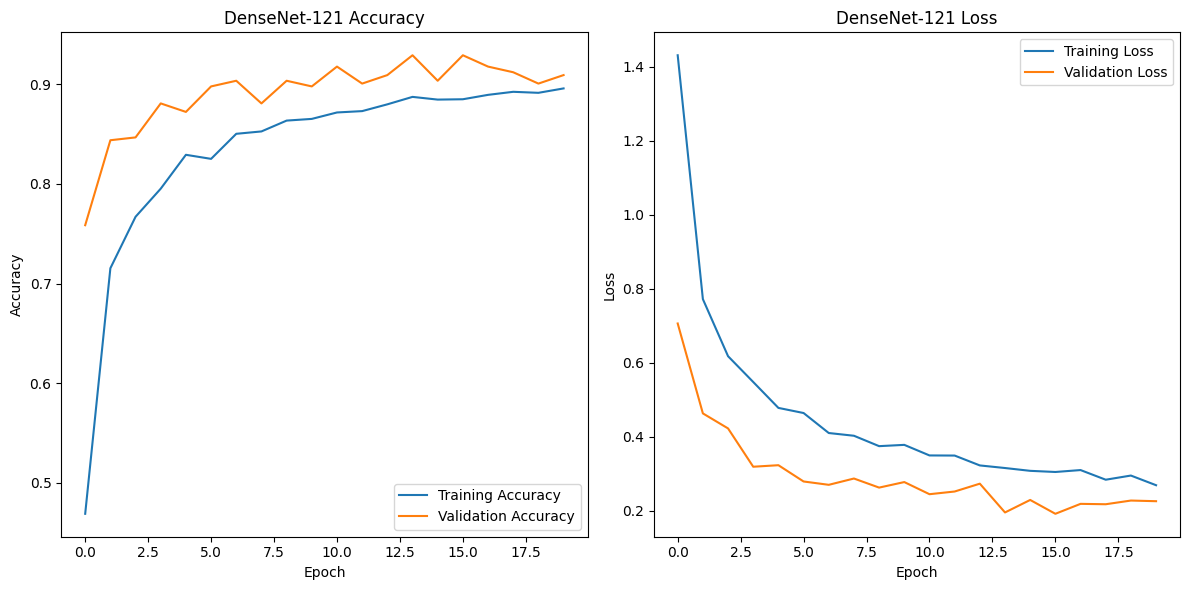

In [46]:
plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
plt.plot(history_densenet.history["accuracy"], label="Training Accuracy")
plt.plot(history_densenet.history["val_accuracy"], label="Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.title("DenseNet-121 Accuracy")

plt.subplot(1, 2, 2)
plt.plot(history_densenet.history["loss"], label="Training Loss")
plt.plot(history_densenet.history["val_loss"], label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("DenseNet-121 Loss")
plt.legend()

plt.tight_layout()
plt.show()

In [47]:
#Get Predictions from Test Set
y_true_dense = []
y_pred_dense = []

for images, labels in test_ds: #showing the predictions for each batch of test dataset
    predictions = densenet_model.predict(images)
    y_true_dense.extend(labels.numpy())
    y_pred_dense.extend(np.argmax(predictions, axis=1))

y_true_dense = np.array(y_true_dense)
y_pred_dense = np.array(y_pred_dense)
print("DenseNet-121 Classification Output for Test set:\n")
print(classification_report(y_true_dense, y_pred_dense, target_names=class_names))

1/1 ━━━━━━━━━━━━━━━━━━━━ 11s 11s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 145ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 148ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 137ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 146ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 132ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 133ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 130ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 125ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 126ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 130ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 11s 11s/step
DenseNet-121 Classification Output for Test set:

              precision    recall  f1-score   support

       daisy       0.92      0.96      0.94        69
   dandelion       0.95      0.90      0.93        91
       roses       0.87      0.95      0.91        58
  sunflowers       0.97      0.96      0.96        71
      tulips       0.94      0.92      0.93        85

    accuracy                           0.93       374
   macro avg       0.93      0.94      0.93       374
weighted avg       0.93      0.93      0.93       

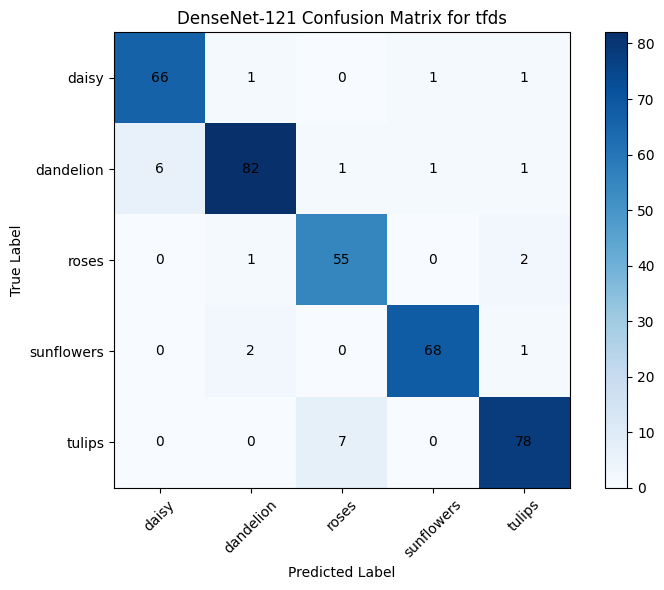

In [48]:
cm = confusion_matrix(y_true_dense, y_pred_dense)

plt.figure(figsize=(8, 6))
plt.imshow(cm,cmap="Blues")
plt.title("DenseNet-121 Confusion Matrix for tfds")
plt.colorbar()

plt.xticks(range(len(class_names)), class_names, rotation=45)
plt.yticks(range(len(class_names)), class_names)

for i in range(len(class_names)):
    for j in range(len(class_names)):
        plt.text(j, i, cm[i, j], ha="center", va="center")

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.tight_layout()
plt.show()

In [49]:
densenet_model.save("densenet_tfds_20.keras")
print("DenseNet-121 model saved successfully.")


DenseNet-121 model saved successfully.
